# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [1]:
! git clone https://github.com/arya-rajesh-99/undergrad_ml_assignments
%run ./undergrad_ml_assignments/get_data.py
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

Cloning into 'undergrad_ml_assignments'...
remote: Enumerating objects: 124, done.
remote: Counting objects: 100% (65/65), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 124 (delta 48), reused 14 (delta 14), pack-reused 59 (from 2)
Receiving objects: 100% (124/124), 16.27 MiB | 10.13 MiB/s, done.
Resolving deltas: 100% (51/51), done.
Download complete
Extracting data files...
Data extracted


In [21]:
airbnb_df = pd.read_csv('./data/airbnb_NYC.csv', encoding='latin1')
airbnb_df.head()

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,5162530,NaN,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,1.0,1,0,145,NaN
1,33134899,NaN,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,11206.0,1.0,1,1,37,NaN
2,39608626,NaN,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,10032.0,1.0,1,1,28,NaN
3,500,6/26/2008,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
4,500,6/26/2008,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0


Neighbourhood 
Manhattan        198.474584
Staten Island    163.462585
Brooklyn         129.500471
Queens           103.222125
Bronx             94.660870
Name: Price, dtype: float64


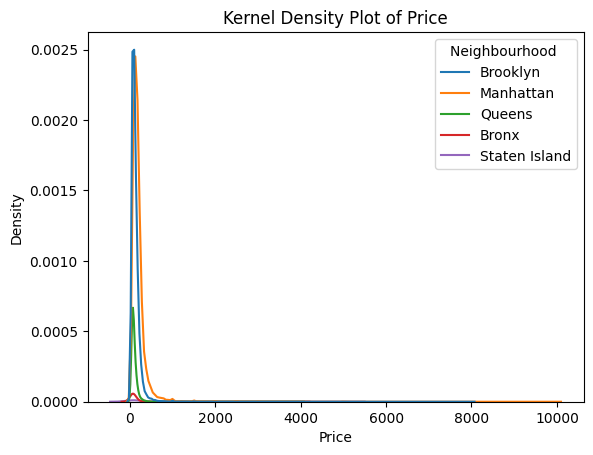

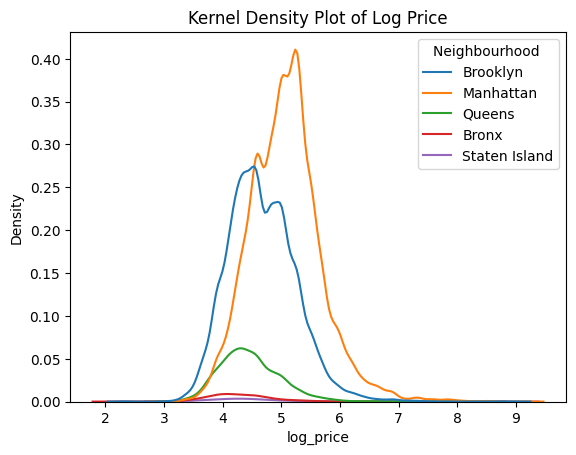

In [28]:
# Question 2.1
airbnb_df.dtypes
#converting price to num
airbnb_df["Price"].astype(str).str.contains(",").any()
airbnb_df["Price"] = (
    airbnb_df["Price"]
    .astype(str)
    .str.replace(",", "", regex=False)
)
airbnb_df["Price"] = pd.to_numeric(airbnb_df["Price"], errors="coerce")
#review score to num
airbnb_df["Review Scores Rating"] = pd.to_numeric(
    airbnb_df["Review Scores Rating"], errors="coerce"
)
#grouping
neighbourhood_avg = airbnb_df.groupby('Neighbourhood ')[['Price', 'Review Scores Rating']].mean()
print(neighbourhood_avg['Price'].sort_values(ascending=False))
# Most expensive on average is Manhattan.

#price kde plot
sns.kdeplot(data=airbnb_df, x="Price", hue="Neighbourhood ")
plt.title('Kernel Density Plot of Price')
plt.show()
#log price kde plot
airbnb_df['log_price'] = np.log(airbnb_df['Price'])
sns.kdeplot(data=airbnb_df, x="log_price", hue="Neighbourhood ")
plt.title('Kernel Density Plot of Log Price')
plt.show()

In [39]:
# Question 2.2
from sklearn.linear_model import LinearRegression
tdf = airbnb_df.loc[:, ['Price', 'Neighbourhood '] ].dropna()
y = tdf['Price']
X_neighbor = pd.get_dummies(tdf['Neighbourhood '], drop_first=True)
model = LinearRegression()
model.fit(X_neighbor, y)
print('Model Intercept:', model.intercept_)
pd.DataFrame({
    'variable': model.feature_names_in_,
    'coefficient': model.coef_
})

Model Intercept: 94.66086956521724


,variable,coefficient
0,Brooklyn,34.839602
1,Manhattan,103.813714
2,Queens,8.561255
3,Staten Island,68.801715


Intercept is the mean price of ommitted neibourhood since drop_first is true.
Each coefficient is the difference from that neighborhood. So the mean is the sum of the two.

In [40]:
# Question 2.3
tdf = airbnb_df.loc[:, ['Price', 'Review Scores Rating'] ].dropna()
y = tdf['Price']
X_num = tdf[['Review Scores Rating']]
model = LinearRegression()
model.fit(X_num, y)
print('Model Intercept:', model.intercept_)
pd.DataFrame({
    'variable': model.feature_names_in_,
    'coefficient': model.coef_
})

Model Intercept: 60.876922431700294


,variable,coefficient
0,Review Scores Rating,1.020844


The slope coefficient means that for every one point increase in the review score rating, there is a 1.02084371 dollar change in price per night.

In [45]:
# Question 2.4
tdf = airbnb_df.loc[:, ['Price', 'Review Scores Rating', 'Neighbourhood ']].dropna()
y = tdf['Price']
X_num = tdf.loc[:, ['Review Scores Rating']]
X_neighbor = pd.get_dummies(tdf['Neighbourhood '], dtype='int', drop_first=True)
X = pd.concat([X_num, X_neighbor], axis=1)
model = LinearRegression()
model = model.fit(X, y)
print('Model Intercept:', model.intercept_)
pd.DataFrame({
    'variable': model.feature_names_in_,
    'coefficient': model.coef_
})

Model Intercept: -23.80878603675302


,variable,coefficient
0,Review Scores Rating,1.081075
1,Brooklyn,51.704269
2,Manhattan,108.223983
3,Queens,21.694595
4,Staten Island,71.766519


The slope coefficient changes to review score rating while maintaining constant neighborhood category. The neighborhood averages show coefficients which are adjusted differences instead of raw mean.

In [44]:
# Question 2.5
tdf = airbnb_df.loc[:, ['Price', 'Review Scores Rating', 'Neighbourhood ']].dropna()
y = tdf['Price']
X_num = tdf.loc[:, ['Review Scores Rating']]
X_neighbor = pd.get_dummies(tdf['Neighbourhood '], dtype='int', drop_first=True)
X = pd.concat([X_num, X_neighbor], axis=1)
for col in X_neighbor.columns:
    X[col + ' Review Scores Rating'] = X_neighbor[col] * tdf['Review Scores Rating']
model = LinearRegression()
model = model.fit(X, y)
print('Model Intercept:', model.intercept_)
pd.DataFrame({
    'variable': model.feature_names_in_,
    'coefficient': model.coef_
})

Model Intercept: 22.638384922076852


,variable,coefficient
0,Review Scores Rating,0.574311
1,Brooklyn,-16.392990
2,Manhattan,41.318763
3,Queens,28.259701
4,Staten Island,2963.071040
5,Brooklyn Review Scores Rating,0.741165
6,Manhattan Review Scores Rating,0.729615
7,Queens Review Scores Rating,-0.072294
8,Staten Island Review Scores Rating,-31.831748


The slope on Review Scores Rating differs across neighbourhoods because additional variables are included that modify the slope. This slope for review scores rating is 0.574. The slopes are not equal across neighbourhoods as shown by the table.

In [47]:
# Question 2.6
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression

tdf = airbnb_df.loc[:, ['Price', 'Review Scores Rating', 'Neighbourhood ']].dropna()
train, test = train_test_split(tdf, test_size=0.2, random_state=0)
y_train = train['Price']
y_test = test['Price']

# Part 3
X_train = train[['Review Scores Rating']]
X_test = test[['Review Scores Rating']]
model = LinearRegression()
model.fit(X_train, y_train)
y_hat = model.predict(X_test)
mse1 = mean_squared_error(y_test, y_hat)
print('Part 3 MSE:', mse1)


# Part 4
X_train_num = train[['Review Scores Rating']]
X_train_neighbor = pd.get_dummies(train['Neighbourhood '], dtype='int', drop_first=True)
X_train = pd.concat([X_train_num, X_train_neighbor], axis=1)
X_test_num = test[['Review Scores Rating']]
X_test_neighbor = pd.get_dummies(test['Neighbourhood '], dtype='int', drop_first=True)
X_test = pd.concat([X_test_num, X_test_neighbor], axis=1)
model = LinearRegression()
model.fit(X_train, y_train)
y_hat = model.predict(X_test)
mse2 = mean_squared_error(y_test, y_hat)
print('Part 4 MSE:', mse2)


# Part 5
X_train_num = train[['Review Scores Rating']]
X_train_neighbor = pd.get_dummies(train['Neighbourhood '], dtype='int', drop_first=True)
X_train = pd.concat([X_train_num, X_train_neighbor], axis=1)
for col in X_train_neighbor.columns:
    X_train[col + ' Review Scores Rating'] = X_train_neighbor[col] * train['Review Scores Rating']
X_test_num = test[['Review Scores Rating']]
X_test_neighbor = pd.get_dummies(test['Neighbourhood '], dtype='int', drop_first=True)
X_test = pd.concat([X_test_num, X_test_neighbor], axis=1)
for col in X_test_neighbor.columns:
    X_test[col + ' Review Scores Rating'] = X_test_neighbor[col] * test['Review Scores Rating']

model = LinearRegression()
model.fit(X_train, y_train)
y_hat = model.predict(X_test)
mse3 = mean_squared_error(y_test, y_hat)
print('Part 5 MSE:', mse3)

Part 3 MSE: 21438.872603485477
Part 4 MSE: 20414.298798241623
Part 5 MSE: 20693.20558126925


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?
